In [6]:
from datasets import load_dataset

dataset = load_dataset("imagefolder", data_dir="dataset")

print(dataset)

Resolving data files:   0%|          | 0/136 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/83 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 136
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 39
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 83
    })
})


In [7]:
print(dataset["train"].features['label'].names)


['landmine', 'not_landmine']


In [8]:
labels = dataset["train"].features["label"].names
num_labels = len(dataset["train"].features["label"].names)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label
print(label2id)
print(id2label)


{'landmine': 0, 'not_landmine': 1}
{0: 'landmine', 1: 'not_landmine'}


In [10]:
import torch
import torch.nn as nn

In [11]:
toy_img = torch.rand(1, 3, 48, 48)
num_channels = 3
hidden_size = 768
patch_size = 16
projection = nn.Conv2d(num_channels, hidden_size, kernel_size=patch_size,
             stride=patch_size)
out_projection = projection(toy_img)
print(f'Original image size: {toy_img.size()}')
print(f'Size after projection: {out_projection.size()}')

Original image size: torch.Size([1, 3, 48, 48])
Size after projection: torch.Size([1, 768, 3, 3])


In [12]:
patch_embeddings = out_projection.flatten(2).transpose(1, 2)
print(f'Patch embedding size: {patch_embeddings.size()}')

Patch embedding size: torch.Size([1, 9, 768])


In [13]:
batch_size = 1
cls_token = nn.Parameter(torch.randn(1, 1, hidden_size))
cls_tokens = cls_token.expand(batch_size, -1, -1)
patch_embeddings = torch.cat((cls_tokens, patch_embeddings), dim=1)
print(f'Patch embedding size: {patch_embeddings.size()}')

Patch embedding size: torch.Size([1, 10, 768])


In [14]:
position_embeddings = nn.Parameter(torch.randn(batch_size, 10, hidden_size))
input_embeddings = patch_embeddings + position_embeddings
print(f'Input embedding size: {input_embeddings.size()}')

Input embedding size: torch.Size([1, 10, 768])


In [15]:
num_heads = 12
num_layers = 12

transformer_encoder_layer = nn.TransformerEncoderLayer(
           d_model=hidden_size, nhead=num_heads,
           dim_feedforward=int(hidden_size * 4),
           dropout=0.1)
transformer_encoder = nn.TransformerEncoder(
           encoder_layer=transformer_encoder_layer,
           num_layers=num_layers)
# Forward pass
output_embeddings = transformer_encoder(input_embeddings)
print(f' Output embedding size: {output_embeddings.size()}')

 Output embedding size: torch.Size([1, 10, 768])


/tmp/ipykernel_24225/3481032949.py:8: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  transformer_encoder = nn.TransformerEncoder(


In [16]:
from transformers import ViTModel

model_checkpoint = 'google/vit-base-patch16-224-in21k'
model = ViTModel.from_pretrained(model_checkpoint, add_pooling_layer=False)

input_img = torch.rand(batch_size, num_channels, 224, 224)

output_embedding = model(input_img)
print(output_embedding)
print(f"Ouput embedding size: {output_embedding['last_hidden_state'].size()}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.weight | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 0.0172, -0.2522,  0.0593,  ...,  0.1425,  0.0475, -0.3657],
         [ 0.0531, -0.1628,  0.0041,  ..., -0.0533,  0.1580, -0.2995],
         [-0.1907, -0.3402, -0.0187,  ...,  0.0764,  0.1795, -0.3721],
         ...,
         [-0.0364, -0.2842,  0.0359,  ...,  0.1361,  0.1152, -0.3893],
         [ 0.0910, -0.0023,  0.0381,  ..., -0.0090,  0.0929, -0.3843],
         [ 0.1876, -0.1293,  0.0099,  ..., -0.0981,  0.1075, -0.3138]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=None, hidden_states=None, attentions=None)
Ouput embedding size: torch.Size([1, 197, 768])


In [17]:
num_labels = 2
classifier = nn.Linear(hidden_size, num_labels)

output_classification = classifier(output_embedding['last_hidden_state'][:, 0, :])
print(f"Output embedding size: {output_classification.size()}")

Output embedding size: torch.Size([1, 2])


In [18]:
probabilities = torch.softmax(output_classification, dim=1)
predicted_class_idx = torch.argmax(probabilities, dim=1).item()
predicted_class_name = id2label[predicted_class_idx]

print(f"Predicted probabilities: {probabilities}")
print(f"Predicted class index: {predicted_class_idx}")
print(f"Predicted class: {predicted_class_name}")

Predicted probabilities: tensor([[0.5438, 0.4562]], grad_fn=<SoftmaxBackward0>)
Predicted class index: 0
Predicted class: landmine


In [19]:
from PIL import Image
import torchvision.transforms as transforms

custom_image_path = '/content/images.jpeg'

try:
    custom_image = Image.open(custom_image_path).convert('RGB')
    print(f'Successfully loaded image from {custom_image_path}')
except FileNotFoundError:
    print(f'Error: Image file not found at {custom_image_path}. Please upload the image.')


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


processed_image = transform(custom_image).unsqueeze(0)

print(f'Processed image size: {processed_image.size()}')

Successfully loaded image from /content/images.jpeg
Processed image size: torch.Size([1, 3, 224, 224])


In [20]:

output_embedding_custom = model(processed_image)
output_classification_custom = classifier(output_embedding_custom['last_hidden_state'][:, 0, :])

probabilities_custom = torch.softmax(output_classification_custom, dim=1)
predicted_class_idx_custom = torch.argmax(probabilities_custom, dim=1).item()
predicted_class_name_custom = id2label[predicted_class_idx_custom]

print(f"Predicted probabilities for custom image: {probabilities_custom}")
print(f"Predicted class index for custom image: {predicted_class_idx_custom}")
print(f"Predicted class for custom image: {predicted_class_name_custom}")

Predicted probabilities for custom image: tensor([[0.5069, 0.4931]], grad_fn=<SoftmaxBackward0>)
Predicted class index for custom image: 0
Predicted class for custom image: landmine


In [38]:
from PIL import Image
import torchvision.transforms as transforms

def predict_custom_image(image_path, model, classifier, id2label):
    """
    Predicts the class of a custom image using the given model.

    Args:
        image_path (str): The file path to the custom image.
        model (torch.nn.Module): The pre-trained Vision Transformer model.
        classifier (torch.nn.Module): The linear classification layer.
        id2label (dict): A dictionary mapping class indices to class names.

    Returns:
        tuple: A tuple containing (probabilities, predicted_class_idx, predicted_class_name).
    """
    try:
        custom_image = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f'Error: Image file not found at {image_path}.')
        return None, None, None


    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])


    processed_image = transform(custom_image).unsqueeze(0)


    output_embedding_custom = model(processed_image)
    output_classification_custom = classifier(output_embedding_custom['last_hidden_state'][:, 0, :])

    probabilities = torch.softmax(output_classification_custom, dim=1)
    predicted_class_idx = torch.argmax(probabilities, dim=1).item()
    predicted_class_name = id2label[predicted_class_idx]

    return probabilities, predicted_class_idx, predicted_class_name


image_path = '/content/images_41.jpeg'
probabilities, class_idx, class_name = predict_custom_image(image_path, model, classifier, id2label)

if probabilities is not None:
    print(f"\nPredicted probabilities for custom image: {probabilities}")
    print(f"Predicted class index for custom image: {class_idx}")
    print(f"Predicted class for custom image: {class_name}")


Predicted probabilities for custom image: tensor([[0.4998, 0.5002]], grad_fn=<SoftmaxBackward0>)
Predicted class index for custom image: 1
Predicted class for custom image: not_landmine


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

Probability for class 'landmine': 0.5357
Probability for class 'not_landmine': 0.4643
Predicted class index for custom image: 0
Predicted class for custom image: landmine


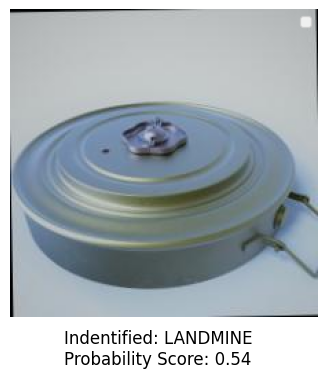

Probability for class 'landmine': 0.4998
Probability for class 'not_landmine': 0.5002
Predicted class index for custom image: 1
Predicted class for custom image: not_landmine


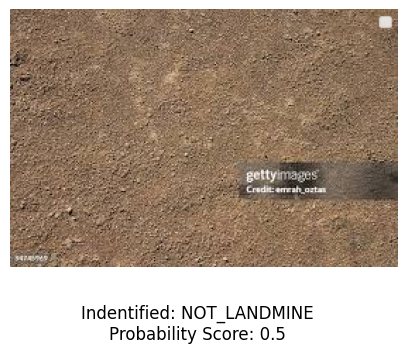

Probability for class 'landmine': 0.5888
Probability for class 'not_landmine': 0.4112
Predicted class index for custom image: 0
Predicted class for custom image: landmine


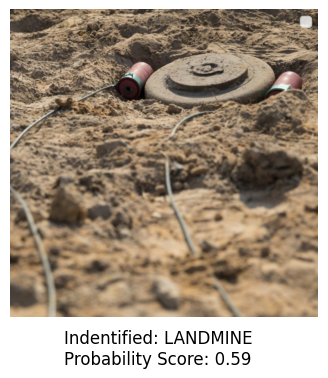

Probability for class 'landmine': 0.5023
Probability for class 'not_landmine': 0.4977
Predicted class index for custom image: 0
Predicted class for custom image: landmine


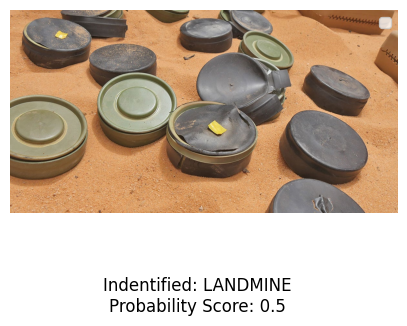

Probability for class 'landmine': 0.5445
Probability for class 'not_landmine': 0.4555
Predicted class index for custom image: 0
Predicted class for custom image: landmine


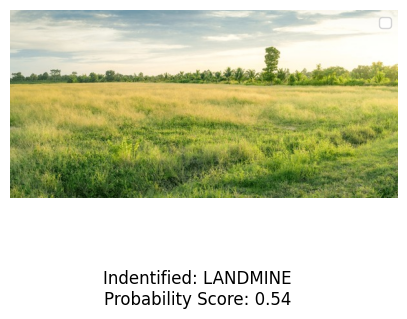

In [46]:
demo_images = ["/content/51.jpg", "/content/images_41.jpeg", "/content/landmine.jpeg", "/content/mines.jpeg", "/content/land.jpeg"]
for image_pt in demo_images:

  probabilities, class_idx, class_name = predict_custom_image(f'{image_pt}', model, classifier, id2label)
  if probabilities is not None:
    # print(f"\nPredicted probabilities for custom image: {probabilities}")
    probability_values = probabilities.squeeze().tolist()
    print(f"Probability for class '{id2label[0]}': {probability_values[0]:.4f}")
    print(f"Probability for class '{id2label[1]}': {probability_values[1]:.4f}")
    print(f"Predicted class index for custom image: {class_idx}")
    print(f"Predicted class for custom image: {class_name}")


    img = mpimg.imread(image_pt)
    plt.figure(figsize=(5, 4))

    predicted_class = id2label[0] if probability_values[0] > probability_values[1] else id2label[1]
    confidence = probability_values[0] if probability_values[0] > probability_values[1] else probability_values[1]

    caption = f"\nIndentified: {predicted_class.upper()}\nProbability Score: {confidence:.2}"
    # print("\nAll probabilities:")
    # for i, prob in enumerate(predictions[0]):
    #     print(f"  {class_names[i]}: {prob:.2%}")
    plt.figtext(0.5,0, caption, wrap=True, horizontalalignment='center', fontsize=12)
    plt.imshow(img)
    plt.axis('off')
    plt.legend("")
    plt.show()
